# Selected aspects in machine learning from the SDE perspective
**Category: Mathematics for New Technologies in Finance**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Generative AI and connection to simple SDEs

Consider the two-dimensional SDE:

$$
dX_t = -\nabla U(X_t)dt+b(X_t)dW_t
$$

where $\mathbb{R}^2\to \mathbb{R}$, and $(W_t)_{t\geq0}$ is one-dimensional Brownian motion and $b:\mathbb{R}^2\to \mathbb{R}^2$. Define
$$
U(x_1,x_2) = \frac{1}{4}(x_1^2-1)^2+\frac{1}{4}(x^2_2-1)^2
$$
and the noise
$$
b_i(x) = \sigma(1+\alpha\tanh(x_i)),\quad i=1,2
$$
with constants $\sigma>0$ and $\alpha\geq 0$

### Discretization

$$
X_{t_k} = X_{t_{k-1}}-\nabla U(X_{t_{k-1}})\Delta t+b(X_{t_{k-1}}) \Delta W_t
$$
if we compute $\nabla U(X_t)$:
$$
\nabla U(X_t) = \begin{pmatrix} X^{(1)}_t \left(\left(X_t^{(1)}\right)^2-1\right)\\ X^{(2)}_t \left(\left(X_t^{(2)}\right)^2-1\right)\end{pmatrix}
$$

In [2]:
def U(X):
    x1 = X[:,0]
    x2 = X[:,1]
    return 1/4* (x1**2-1)**2+1/4*(x2**2-1)**2

def nablaU(X):
    return X*(X**2-1)

def b(X,alpha,sigma):
    return sigma*(1+alpha*np.tanh(X))

def gen_brownianM(T,M,N):
    dt = T/M
    W = np.zeros(shape=(M+1,N))
    for t in range(1,M+1):
        W[t,:] = W[t-1,:] + np.sqrt(dt)* np.random.normal(size=N)

    return W

def eulerM(X0,T,M,N,alpha,sigma):
    dt = T/M
    X = np.zeros(shape=(M+1,2,N))
    X[0,:,:] = X0
    for k in range(1,M+1):
        X[k,:,:] = X[k-1,:,:]-nablaU(X[k-1,:,:])*dt+b(X[k-1,:,:],alpha,sigma)*np.sqrt(dt)*np.random.normal(size=(1,N))
    return X




In [24]:
np.random.seed(2)

T=10;M=10**4;N=10**4
X0 = np.random.normal(size=(2,N))

alpha_v = np.linspace(0,0.8,4)
sigma_v = np.linspace(0.1,0.5,3)
X_coll = []
X_labels = []
for i in range(len(alpha_v)):
    for j in range(len(sigma_v)):
        alpha = alpha_v[i]; sigma = sigma_v[j]
        X = eulerM(X0,T=T,M=M,N=N,alpha=alpha,sigma=sigma)
        X_coll.append(X)
        X_labels.append(fr"$\alpha$={round(alpha,3)}, $\sigma$={round(sigma,3)}")

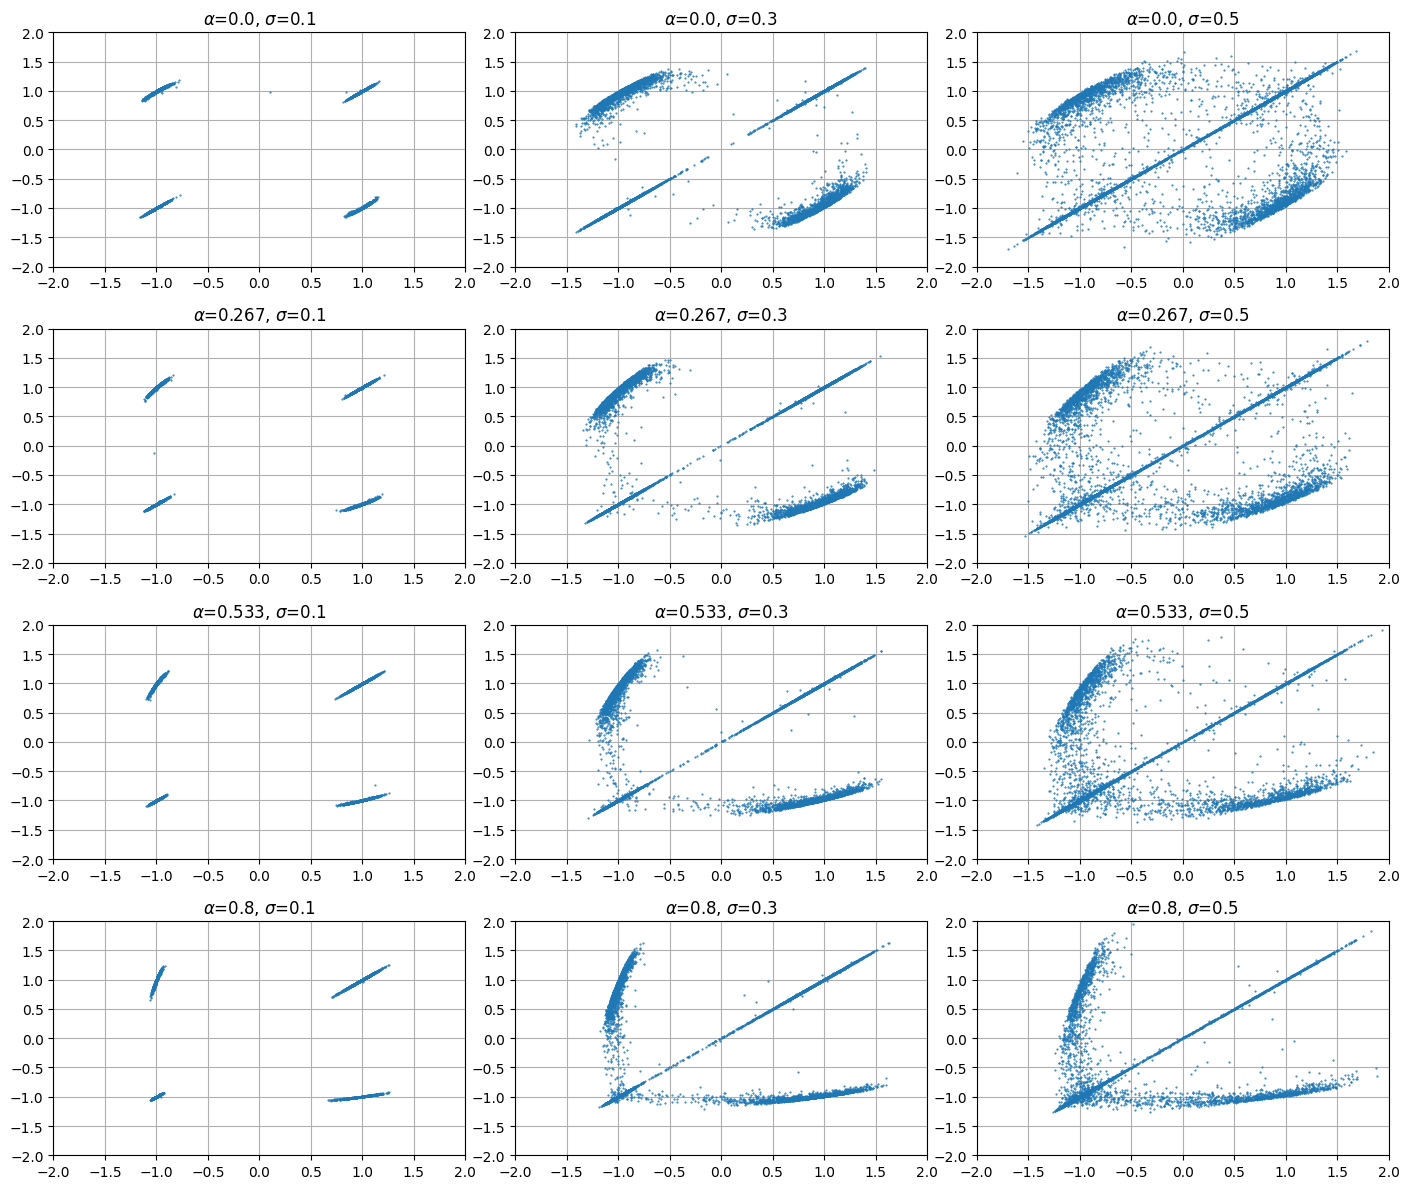

In [25]:
fig = plt.figure(figsize=(14,12))
for i in range(len(alpha_v)):
    for j in range(len(sigma_v)):
        c = j+i*(len(alpha_v)-1)
        plt.subplot(len(alpha_v),len(sigma_v),c+1)
        X_cur = X_coll[c]
        X_lab = X_labels[c]
        plt.plot(X_cur[-1,0,:],X_cur[-1,1,:],'.',markersize=1)
        plt.grid(True)
        plt.title(X_lab)
        plt.ylim((-2,2))
        plt.xlim((-2,2))

plt.tight_layout()
plt.show()
        



We note that as $\alpha$ grows the signal from the data is strengthened in the noise term, which affects the tilt in the clouds which appear in the corners. In short the geometry of the data is extremely sensitive to noise, and making the noise dependent on the input itself breaks the assymetry. 

In the context of Generative AI this matters alot, namely
* With the noise independent of the signal this becomes a task that can be solved locally once and be applied to the other regions
* As the dependence grows the complexity of the task increases, one locally solved problem in one of the corners might generalize poorly
* Eventhough this experiment is rather simplistic, it provides the idea on how to test how well a particular model generalizes (e.g. train a non-trivial model in one region, test it in others and observe, it is highly unlikely that the model will do well globally straight out-of-box)
* Lastly, with increased noise and a strong dependency on the signal, the task becomes extremely complicated very fast, for instance with $\sigma=0.5$ and $\alpha=0$ the task is noisy, but the seperability is clear (almost linear actually), but under the same $\sigma$ and $\alpha=0.8$, the seperability is not so clear (even a human could argue that there are only three regions now, the diagonal, and the two other corners), so for a model to seperate the regions becomes a more delicate task (and even somewhat unclear on what is correct, which is identical to real-world problems).


There are many aspects to the signal design as well, it might be a clever design to make the model sweat a little, on such tasks. But it is highly dependent on the goal, think of the following:
* Task1: visual task to seperate red/yellow and green, e.g. autonomous vehicle at traffic lights, some signal dependence in the noise might be a clever design (when simulating data that is), why, well in real life these are colors but lighting, weather, contrast etc changes, so some middleground might be ideal but we also note that there are traffic light with only yellow, so this is a great example
* Task2: analyse standarized texts, there might be grammarical errors and a few caveats but nothing should fundamentally should change, so we're probably better off in the lighter dep. frame (unless we wanted to analyse different texts as well, which is not the task)

## 2. NNs and training dynamics

Let us consider a the function $f:[-\pi,\pi]\to \mathcal{Y}$, with $\mathcal{Y} \subset \mathbb{R}$, and the mapping $x\mapsto \sin(x)$

In [27]:
import torch
import torch.nn as nn

In [28]:
N_s = 10**4
x = np.linspace(-np.pi,np.pi,N_s)
y = np.sin(x)

In [124]:
def createNet():
    torch.manual_seed(0)
    net = nn.Sequential(
    nn.Linear(1,20),
        nn.Tanh(),
    nn.Linear(20,1)
    ).double()
    print(net)
    return net


Note: the selection of the hyperbolic tangent might by a bit biased, for it is a function highly related to the objective. Nevertheless, it is in general a clever choice, for it is smooth (hence differentiable everywhere) and normalizes the signal on scale from $[-1,1]$, it should prevent explosions in the gradient, and lastly it simple and well studied.

In [208]:
def train_net(model,train_prop,X,Y,epochs,lr,train_meth,train_coef):
    """
    train_meth:
        "FULL_BATCH", train_coef = None
        "MINI_BATCH", train_coef = batch_size (int)
        "STOCHASTIC", train_coef = None
        "LANGEVIN", train_coef = sigma (float)
    """

    torch.manual_seed(0)
    np.random.seed(0)


    N = len(X)
    M = int(N*train_prop)
    X = torch.tensor(X).unsqueeze(1); Y = torch.tensor(Y).unsqueeze(1)
    loss_fn = nn.MSELoss()
    opt = torch.optim.SGD(model.parameters(),lr=lr)
    train_loss, test_loss = [],[]
    X_train,Y_train = X[:M],Y[:M]
    X_test,Y_test = X[M:],Y[M:]
    train_idx_arr = torch.arange(M,dtype=float)
    test_idx_arr = torch.arange(N-M,dtype=float)

    if train_meth == "FULL_BATCH":
        print(f"\n--- {train_meth} ---\n")

        for e in range(epochs):
            opt.zero_grad()
            pred = model(X_train)
            loss = loss_fn(pred,Y_train)
            loss.backward()
            opt.step()
            l_train = loss.item()
        
            with torch.no_grad():
                l_test = loss_fn(model(X_test),Y_test).item()

            train_loss.append(l_train)
            test_loss.append(l_test)

            if e % int(epochs/3) == 0:
                print(f"\nStatus {e}/{epochs}:")
                print(f"Training Loss: {l_train:.4e}, Test Loss: {l_test:.4e}")

    if train_meth == "MINI_BATCH":
        print(f"\n--- {train_meth} ---\n")

        batch_size = train_coef
        for e in range(epochs):
            opt.zero_grad()
            train_idx = train_idx_arr.multinomial(num_samples=batch_size,replacement=True)
            test_idx = test_idx_arr.multinomial(num_samples=batch_size,replacement=True)

            pred = model(X_train[train_idx])
            loss = loss_fn(pred,Y_train[train_idx])
            loss.backward()
            opt.step()

            l_train = loss.item()
        
            with torch.no_grad():
                l_test = loss_fn(model(X_test[test_idx]),Y_test[test_idx]).item()

            train_loss.append(l_train)
            test_loss.append(l_test)

            if e % int(epochs/3) == 0:
                print(f"\nStatus {e}/{epochs}:")
                print(f"Training Loss: {l_train:.4e}, Test Loss: {l_test:.4e}")


    if train_meth == "STOCHASTIC":
        print(f"\n--- {train_meth} ---\n")
        batch_size = 1
        for e in range(epochs):
            opt.zero_grad()
            train_idx = train_idx_arr.multinomial(num_samples=batch_size,replacement=True)
            test_idx = test_idx_arr.multinomial(num_samples=batch_size,replacement=True)

            pred = model(X_train[train_idx])
            loss = loss_fn(pred,Y_train[train_idx])
            loss.backward()
            opt.step()

            l_train = loss.item()
        
            with torch.no_grad():
                l_test = loss_fn(model(X_test[test_idx]),Y_test[test_idx]).item()

            train_loss.append(l_train)
            test_loss.append(l_test)

            if e % int(epochs/3) == 0:
                print(f"\nStatus {e}/{epochs}:")
                print(f"Training Loss: {l_train:.4e}, Test Loss: {l_test:.4e}")


    if train_meth == "LANGEVIN":
        print(f"\n--- {train_meth} ---\n")
        sigma = train_coef
        for e in range(epochs):
            opt.zero_grad()
            pred = model(X_train)
            loss = loss_fn(pred,Y_train)
            loss.backward()
            opt.step()


            with torch.no_grad():
                for param in model.parameters():
                    param.data += sigma*np.sqrt(lr)*torch.normal(mean=torch.tensor(0.),std=torch.tensor(1.),out=torch.tensor(1.))

            l_train = loss.item()
        
            with torch.no_grad():
                l_test = loss_fn(model(X_test),Y_test).item()

            train_loss.append(l_train)
            test_loss.append(l_test)

            if e % int(epochs/3) == 0:
                print(f"\nStatus {e}/{epochs}:")
                print(f"Training Loss: {l_train:.4e}, Test Loss: {l_test:.4e}")


    return train_loss,test_loss,model,X_train,Y_train,X_test,Y_test,train_coef



In [272]:
net1 = createNet()
net2 = createNet()
net3 = createNet()
net4 = createNet()
net5 = createNet()
net6 = createNet()



epochs = 10000
train_prop = 0.9
lr=0.01

L1_train,L1_test,FB_net,X_train,Y_train,X_test,Y_test,_= train_net(
    model=net1,train_prop=train_prop,X=x,Y=y,epochs=epochs,lr=lr,train_meth="FULL_BATCH",train_coef=None)
L2_1_train,L2_1_test,MB_1_net,_,_,_,_,MB1_tC= train_net(
    model=net2,train_prop=train_prop,X=x,Y=y,epochs=epochs,lr=lr,train_meth="MINI_BATCH",train_coef=32)
L2_2_train,L2_2_test,MB_2_net,_,_,_,_,MB2_tC= train_net(
    model=net3,train_prop=train_prop,X=x,Y=y,epochs=epochs,lr=lr,train_meth="MINI_BATCH",train_coef=2)
L3_train,L3_test,S_net,_,_,_,_,_= train_net(
    model=net4,train_prop=train_prop,X=x,Y=y,epochs=epochs,lr=lr,train_meth="STOCHASTIC",train_coef=None)
L4_1_train,L4_1_test,L1_net,_,_,_,_,L1_tC= train_net(
    model=net5,train_prop=train_prop,X=x,Y=y,epochs=epochs,lr=lr,train_meth="LANGEVIN",train_coef=0.05)
L4_2_train,L4_2_test,L2_net,_,_,_,_,L2_tC= train_net(
    model=net6,train_prop=train_prop,X=x,Y=y,epochs=epochs,lr=lr,train_meth="LANGEVIN",train_coef=0.1)

Sequential(
  (0): Linear(in_features=1, out_features=20, bias=True)
  (1): Tanh()
  (2): Linear(in_features=20, out_features=1, bias=True)
)
Sequential(
  (0): Linear(in_features=1, out_features=20, bias=True)
  (1): Tanh()
  (2): Linear(in_features=20, out_features=1, bias=True)
)
Sequential(
  (0): Linear(in_features=1, out_features=20, bias=True)
  (1): Tanh()
  (2): Linear(in_features=20, out_features=1, bias=True)
)
Sequential(
  (0): Linear(in_features=1, out_features=20, bias=True)
  (1): Tanh()
  (2): Linear(in_features=20, out_features=1, bias=True)
)
Sequential(
  (0): Linear(in_features=1, out_features=20, bias=True)
  (1): Tanh()
  (2): Linear(in_features=20, out_features=1, bias=True)
)
Sequential(
  (0): Linear(in_features=1, out_features=20, bias=True)
  (1): Tanh()
  (2): Linear(in_features=20, out_features=1, bias=True)
)

--- FULL_BATCH ---


Status 0/10000:
Training Loss: 5.7278e-01, Test Loss: 4.3498e-02

Status 3333/10000:
Training Loss: 4.3828e-03, Test Loss: 1.7

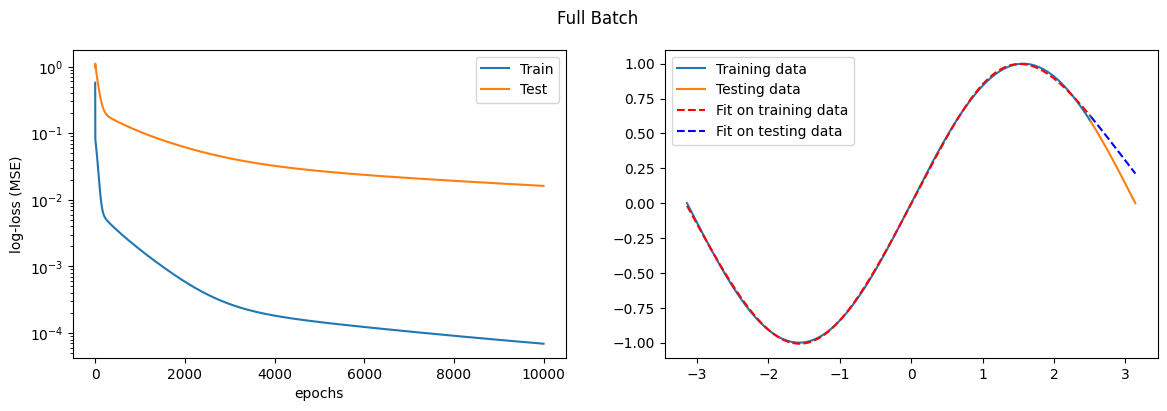

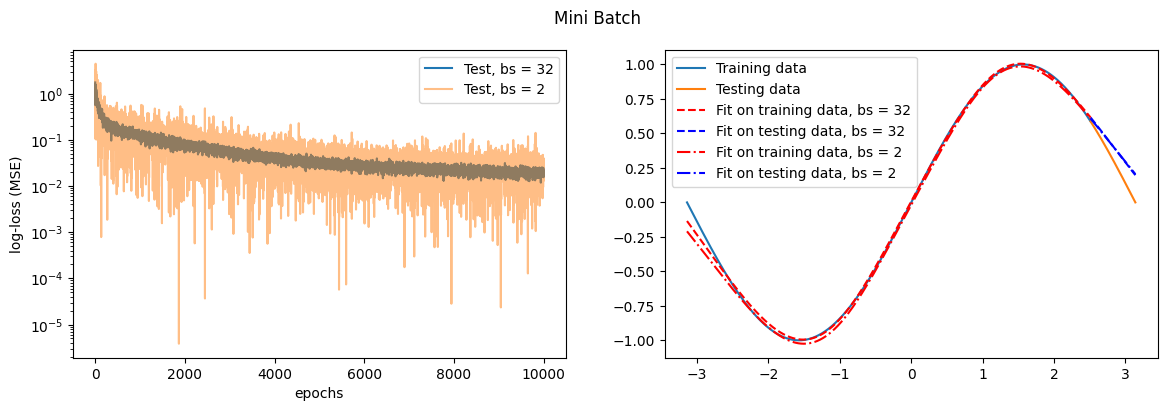

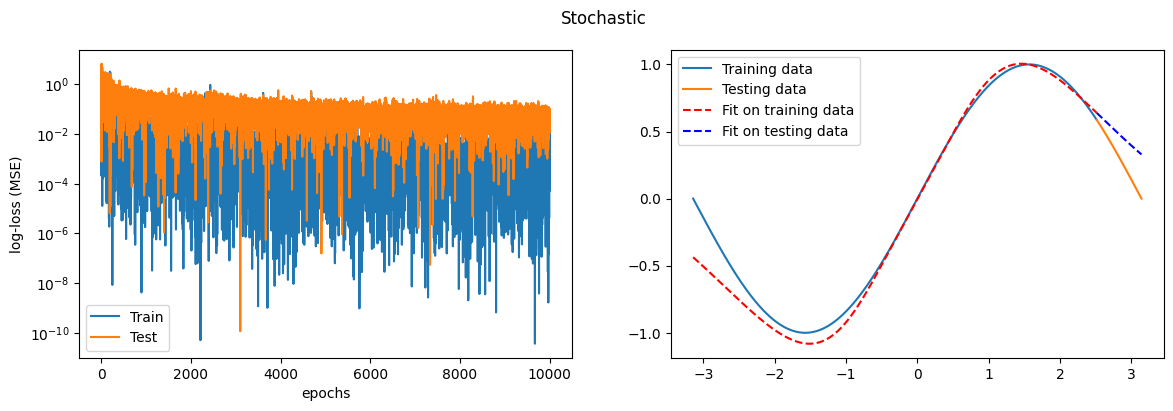

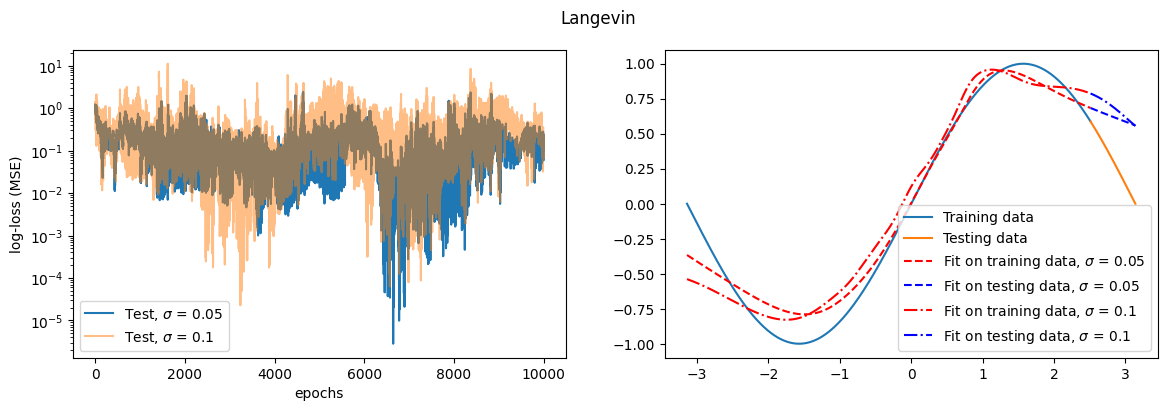

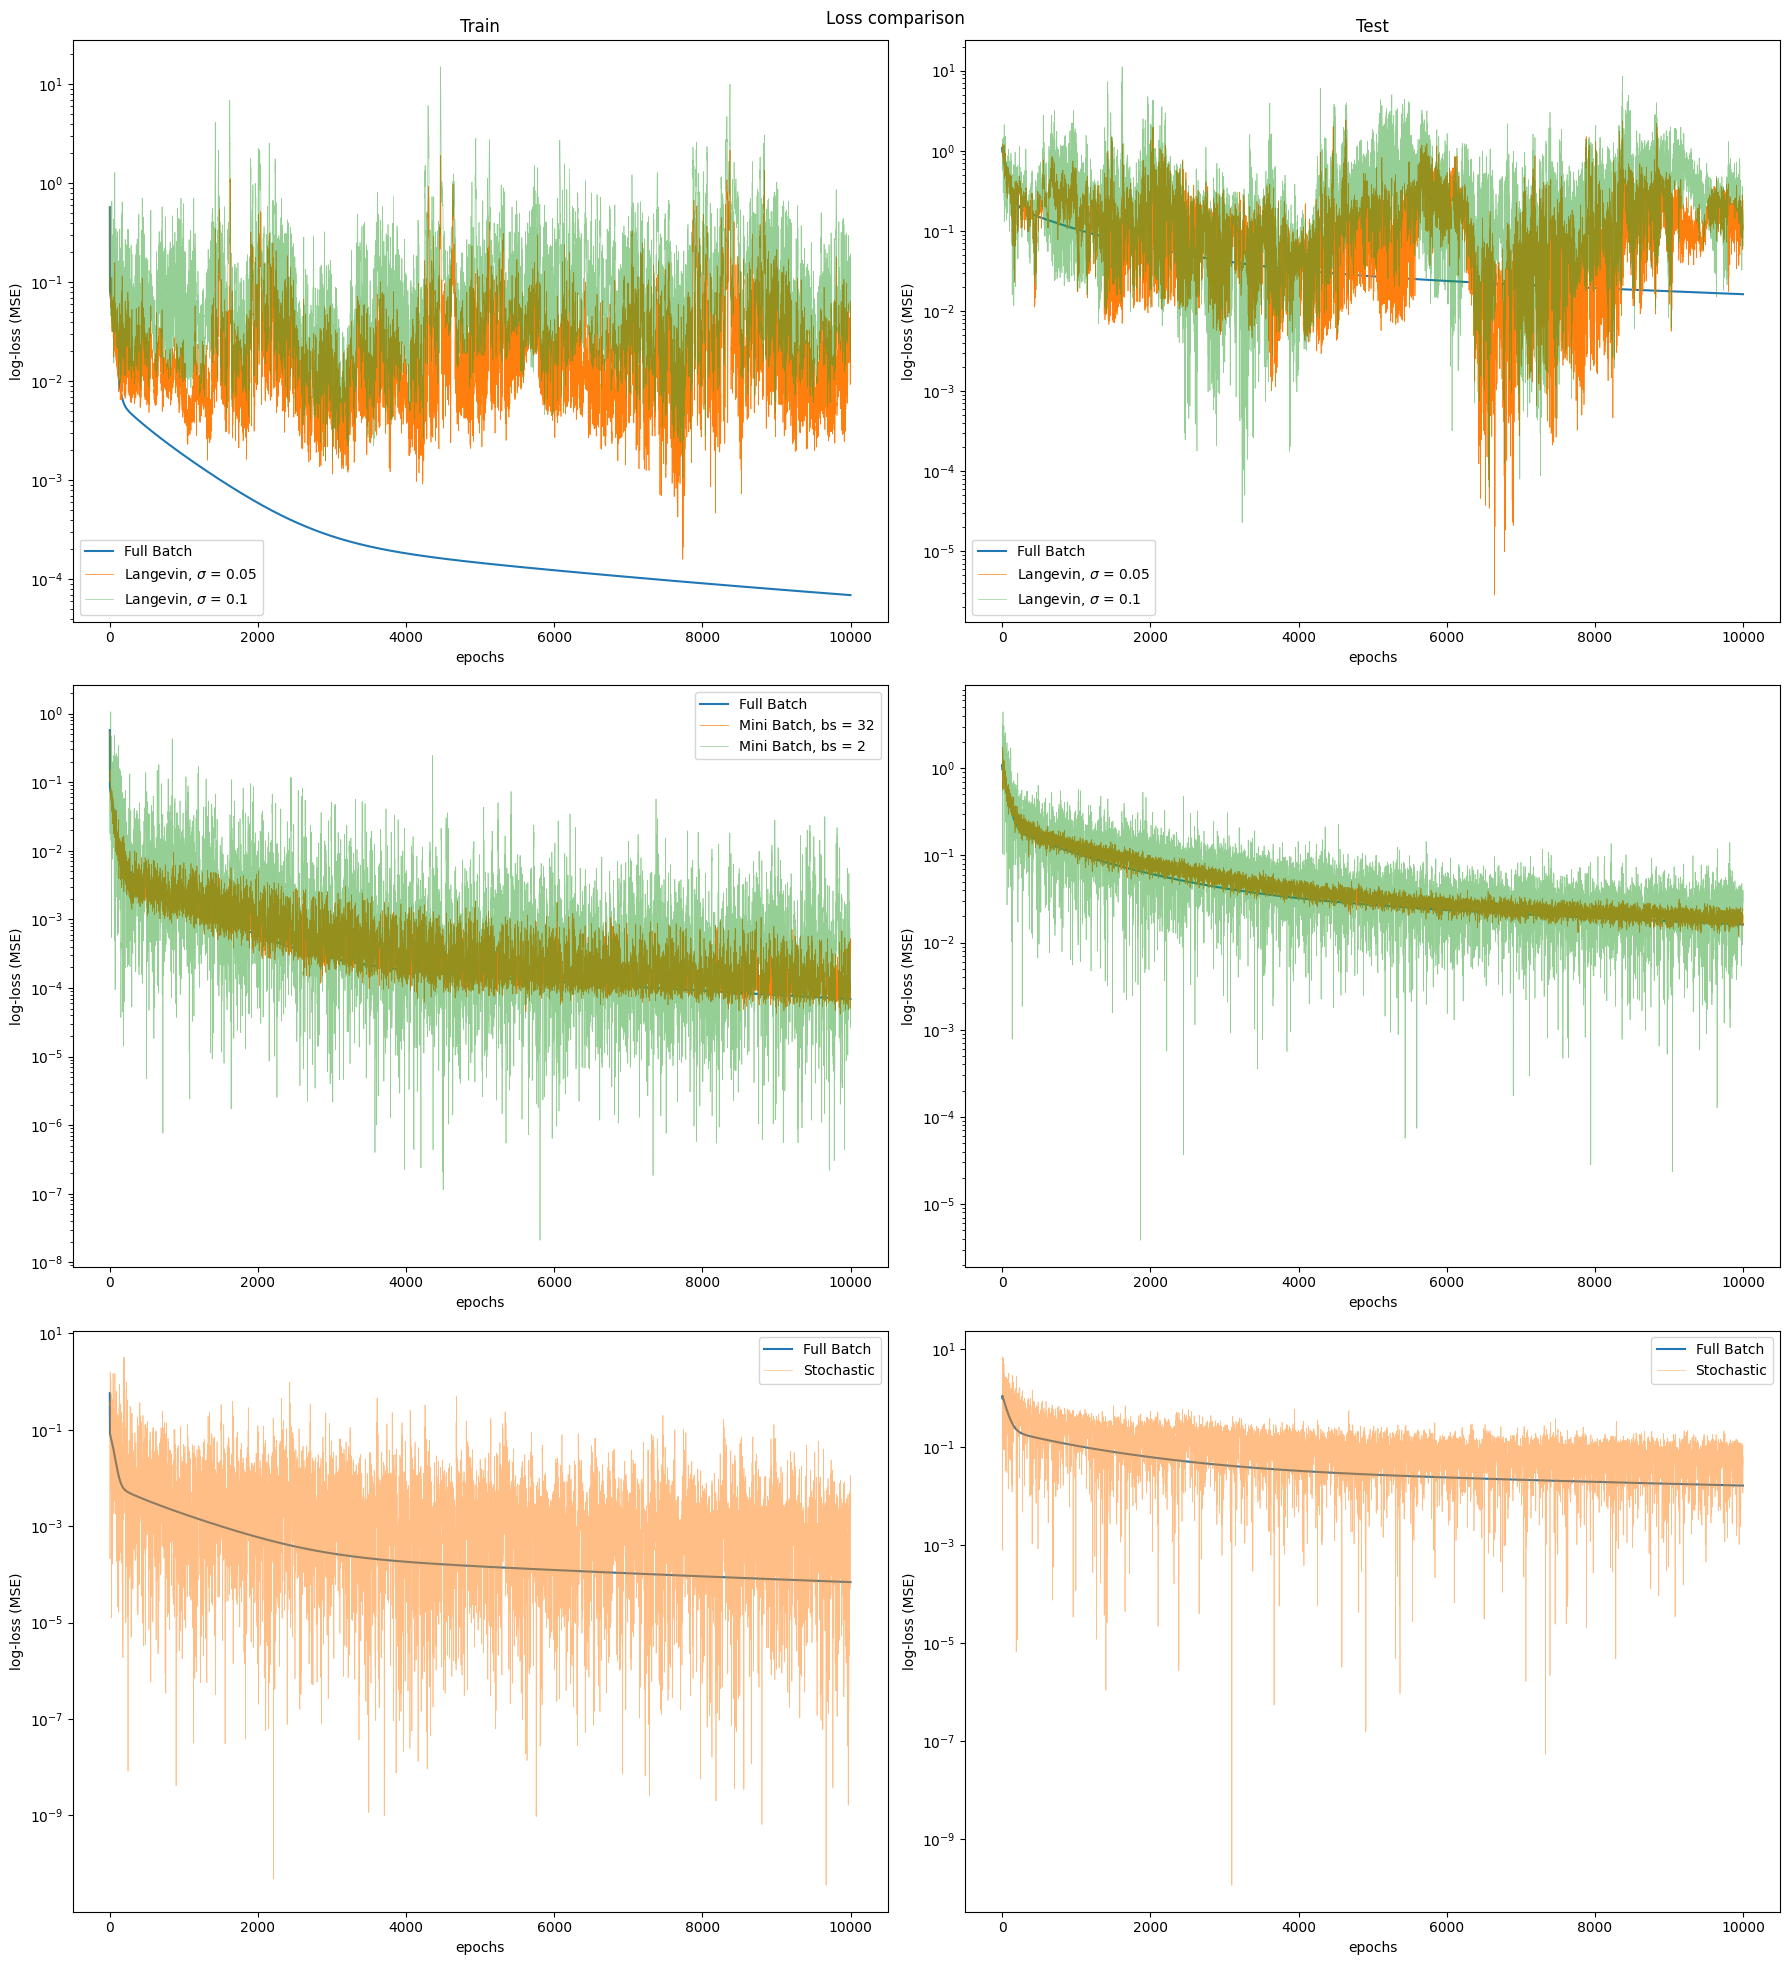

In [270]:
fig = plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
plt.plot(L1_train,label="Train")
plt.plot(L1_test,label="Test")
plt.yscale('log')
plt.ylabel("log-loss (MSE)")
plt.xlabel("epochs")
plt.legend()

plt.subplot(1,2,2)
plt.plot(X_train,Y_train,label="Training data")
plt.plot(X_test,Y_test,label="Testing data")
plt.plot(X_train,FB_net(X_train).detach().numpy(),'r--',label="Fit on training data")
plt.plot(X_test,FB_net(X_test).detach().numpy(),'b--',label="Fit on testing data")
plt.legend()
plt.suptitle("Full Batch")
plt.show()

fig = plt.figure(figsize=(14,4))

plt.subplot(1,2,1)
# plt.plot(L2_1_train,label=f"Train, bs = {MB1_tC}")
plt.plot(L2_1_test,label=f"Test, bs = {MB1_tC}")
# plt.plot(L2_2_train,label=f"Train, bs = {MB2_tC}",alpha=0.5)
plt.plot(L2_2_test,label=f"Test, bs = {MB2_tC}",alpha=0.5)
plt.yscale('log')
plt.ylabel("log-loss (MSE)")
plt.xlabel("epochs")
plt.legend()

plt.subplot(1,2,2)
plt.plot(X_train,Y_train,label="Training data")
plt.plot(X_test,Y_test,label="Testing data")

plt.plot(X_train,MB_1_net(X_train).detach().numpy(),'r--',label=f"Fit on training data, bs = {MB1_tC}")
plt.plot(X_test,MB_1_net(X_test).detach().numpy(),'b--',label=f"Fit on testing data, bs = {MB1_tC}")
plt.plot(X_train,MB_2_net(X_train).detach().numpy(),'r-.',label=f"Fit on training data, bs = {MB2_tC}")
plt.plot(X_test,MB_2_net(X_test).detach().numpy(),'b-.',label=f"Fit on testing data, bs = {MB2_tC}")

plt.legend()
plt.suptitle(f"Mini Batch")
plt.show()



fig = plt.figure(figsize=(14,4))

plt.subplot(1,2,1)
plt.plot(L3_train,label="Train")
plt.plot(L3_test,label="Test")
plt.yscale('log')
plt.ylabel("log-loss (MSE)")
plt.xlabel("epochs")
plt.legend()

plt.subplot(1,2,2)
plt.plot(X_train,Y_train,label="Training data")
plt.plot(X_test,Y_test,label="Testing data")
plt.plot(X_train,S_net(X_train).detach().numpy(),'r--',label="Fit on training data")
plt.plot(X_test,S_net(X_test).detach().numpy(),'b--',label="Fit on testing data")
plt.legend()
plt.suptitle(f"Stochastic")
plt.show()


fig = plt.figure(figsize=(14,4))

plt.subplot(1,2,1)
# plt.plot(L4_1_train,label=f"Train, $\sigma$ = {L1_tC}")
plt.plot(L4_1_test,label=f"Test, $\sigma$ = {L1_tC}")
# plt.plot(L4_2_train,label=f"Train, $\sigma$ = {L2_tC}",alpha=0.5)
plt.plot(L4_2_test,label=f"Test, $\sigma$ = {L2_tC}",alpha=0.5)
plt.yscale('log')
plt.ylabel("log-loss (MSE)")
plt.xlabel("epochs")
plt.legend()

plt.subplot(1,2,2)
plt.plot(X_train,Y_train,label="Training data")
plt.plot(X_test,Y_test,label="Testing data")

plt.plot(X_train,L1_net(X_train).detach().numpy(),'r--',label=f"Fit on training data, $\sigma$ = {L1_tC}")
plt.plot(X_test,L1_net(X_test).detach().numpy(),'b--',label=f"Fit on testing data, $\sigma$ = {L1_tC}")
plt.plot(X_train,L2_net(X_train).detach().numpy(),'r-.',label=f"Fit on training data, $\sigma$ = {L2_tC}")
plt.plot(X_test,L2_net(X_test).detach().numpy(),'b-.',label=fr"Fit on testing data, $\sigma$ = {L2_tC}")

plt.legend()
plt.suptitle(f"Langevin")
plt.show()




fig = plt.figure(figsize=(18,20))

plt.subplot(3,2,1)
plt.title("Train")
plt.plot(L1_train,label="Full Batch")


plt.plot(L4_1_train,label=f"Langevin, $\sigma$ = {L1_tC}",lw=0.5)
plt.plot(L4_2_train,label=f"Langevin, $\sigma$ = {L2_tC}",alpha=0.5,lw=0.5)
plt.yscale('log')
plt.ylabel("log-loss (MSE)")
plt.xlabel("epochs")
plt.legend()

plt.subplot(3,2,2)
plt.title("Test")
plt.plot(L1_test,label="Full Batch")


plt.plot(L4_1_test,label=f"Langevin, $\sigma$ = {L1_tC}",lw=0.5)
plt.plot(L4_2_test,label=f"Langevin, $\sigma$ = {L2_tC}",alpha=0.5,lw=0.5)
plt.yscale('log')
plt.ylabel("log-loss (MSE)")
plt.xlabel("epochs")

plt.legend()
plt.suptitle(f"Loss comparison")


plt.subplot(3,2,3)
plt.plot(L1_train,label="Full Batch")


plt.plot(L2_1_train,label=f"Mini Batch, bs = {MB1_tC}",lw=0.5)
plt.plot(L2_2_train,label=f"Mini Batch, bs = {MB2_tC}",alpha=0.5,lw=0.5)
plt.yscale('log')
plt.ylabel("log-loss (MSE)")
plt.xlabel("epochs")
plt.legend()

plt.subplot(3,2,4)
plt.plot(L1_test,label="Full Batch")


plt.plot(L2_1_test,label=f"Mini Batch, bs = {MB1_tC}",lw=0.5)
plt.plot(L2_2_test,label=f"Mini Batch, bs = {MB2_tC}",alpha=0.5,lw=0.5)
plt.yscale('log')
plt.ylabel("log-loss (MSE)")
plt.xlabel("epochs")


plt.subplot(3,2,5)
plt.plot(L1_train,label="Full Batch")
plt.plot(L3_train,label="Stochastic",alpha=0.5,lw=0.5)
plt.yscale('log')
plt.ylabel("log-loss (MSE)")
plt.xlabel("epochs")
plt.legend()

plt.subplot(3,2,6)
plt.plot(L1_test,label="Full Batch")
plt.plot(L3_test,label="Stochastic",alpha=0.5,lw=0.5)

plt.yscale('log')
plt.ylabel("log-loss (MSE)")
plt.xlabel("epochs")

plt.legend()
plt.suptitle(f"Loss comparison")
plt.tight_layout()
plt.show()




In [273]:
print(f"Full batch: \t\t{L1_test[-1]}")
print(f"Mini batch, bs {MB1_tC}: \t{L2_1_test[-1]}")
print(f"Mini batch, bs {MB2_tC}: \t{L2_2_test[-1]}")
print(f"Stochastic: \t\t{L3_test[-1]}")
print(f"Langevin, sigma {L1_tC}:   {L4_1_test[-1]}")
print(f"Langevin, sigma {L2_tC}:    {L4_2_test[-1]}")


Full batch: 		0.10507870328581483
Mini batch, bs 32: 	0.13747338092331954
Mini batch, bs 2: 	0.16035131269563127
Stochastic: 		0.10329867499364273
Langevin, sigma 0.05:   0.03163562985401116
Langevin, sigma 0.1:    0.012860479448594251


Generally speaking:
* Full Batch is slower, but very stable, allows larger stepsize
* "Stochastic" is very fast, but extremely volatile, needs to be tuned very carefully (not ideal to use raw)
* Mini Batch (for the appropriate batchsize), faster than full batch and more stable than stochastic (ideal to use for one can choose stability,speed or a mix)
* Langevin is similar to full batch but introduces slight noise, that potentially aids in learning (notably the noise comes from an independent source not the data itself, hence for smaller dataset it might be ideal, since you eventually run out of truly random samples)

Remarks 1: for a more rigorous argument, one needs much greater simulations, and convergence arguments.

Remarks 2: the results above show that the Langevin dynamics yielded the lowest test loss, that might truly be luck, but commonly it works remarkely full for smaller stepsizes (as in the case above). (Naive test case)